In [1]:
# import all necessary libraries

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
from torch import nn
import torchvision
import numpy as np

import matplotlib.pyplot as plt
print(torch.__version__)

1.10.0


In [2]:
!nvidia-smi

Tue Jan 27 15:18:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:04:00.0 Off |                    0 |
| N/A   40C    P0             53W /  300W |       4MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Select Cuda Device to work on
device_number = "2"
device = torch.device(f"cuda:{device_number}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:2


Load the necessary data and create train test splits

In [4]:
# Load the saved data
all_img = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_img_bev.pt')
all_pts = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_pts_bev.pt')

print("all_img shape:", all_img["img_bev_embed"].shape, "all_pts shape:", all_pts["pts_bev_embed"].shape)
print("all_img dtype:", all_img["img_bev_embed"].dtype, "all_pts dtype:", all_pts["pts_bev_embed"].dtype)
print("all_img keys:", all_img.keys(), "all_pts keys:", all_pts.keys())
print("all_img device:", all_img["img_bev_embed"].device, "all_pts device:", all_pts["pts_bev_embed"].device)


one_sample_training = torch.load('/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_cnw_256_one_sample_mininuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951/vis_data.pt')
X_test_one = one_sample_training["img_bev_embed"]
y_test_one = one_sample_training["pts_bev_embed"]
print("one_sample_img shape:", X_test_one.shape, "one_sample_pts shape:", y_test_one.shape)
print("one_sample_img dtype:", X_test_one.dtype, "one_sample_pts dtype:", y_test_one.dtype)

all_img shape: torch.Size([81, 40000, 256]) all_pts shape: torch.Size([81, 40000, 256])
all_img dtype: torch.float32 all_pts dtype: torch.float32
all_img keys: dict_keys(['img_bev_embed', 'lidar_file_name']) all_pts keys: dict_keys(['pts_bev_embed', 'lidar_file_name'])
all_img device: cpu all_pts device: cpu
one_sample_img shape: torch.Size([1, 40000, 256]) one_sample_pts shape: torch.Size([1, 40000, 256])
one_sample_img dtype: torch.float32 one_sample_pts dtype: torch.float32


In [5]:
# Sanity check of data
all_img['img_bev_embed']

tensor([[[-1.0155e-01, -1.0783e-01,  7.4267e-02,  ...,  2.0826e-01,
           6.6576e-02, -9.3027e-03],
         [-8.9726e-02, -1.1311e-01,  6.0293e-02,  ...,  2.1556e-01,
           6.6872e-02, -1.2682e-02],
         [-9.6111e-02, -1.8983e-01,  6.8685e-02,  ...,  2.1616e-01,
           7.2010e-02, -2.7745e-02],
         ...,
         [ 2.9830e-01,  2.9875e-01,  4.8851e-02,  ...,  3.2833e-01,
           7.8780e-02,  6.4390e-02],
         [ 3.0128e-01,  2.8913e-01,  4.2466e-02,  ...,  3.3161e-01,
           8.4799e-02,  5.8628e-02],
         [ 3.0716e-01,  2.8416e-01,  5.0311e-02,  ...,  3.2524e-01,
           8.2926e-02,  6.3762e-02]],

        [[-6.7744e-02, -4.1755e-01,  1.6819e-01,  ...,  3.6113e-01,
           5.2394e-02, -1.0108e-01],
         [-3.4708e-02, -4.0342e-01,  1.6600e-01,  ...,  3.6967e-01,
           5.1502e-02, -1.0065e-01],
         [-6.8644e-03, -3.9745e-01,  1.6894e-01,  ...,  3.6446e-01,
           5.0225e-02, -1.0809e-01],
         ...,
         [-9.4046e-02, -3

In [6]:
img_bev_embed = all_img["img_bev_embed"]
pts_bev_embed = all_pts["pts_bev_embed"]

print("final img_bev_embed info:")
print("  shape:", img_bev_embed.shape, "dtype:", img_bev_embed.dtype, "device:", img_bev_embed.device)

print("final pts_bev_embed info:")
print("  shape:", pts_bev_embed.shape, "dtype:", pts_bev_embed.dtype, "device:", pts_bev_embed.device)

final img_bev_embed info:
  shape: torch.Size([81, 40000, 256]) dtype: torch.float32 device: cpu
final pts_bev_embed info:
  shape: torch.Size([81, 40000, 256]) dtype: torch.float32 device: cpu


In [7]:
# Reshape to spatial dimensions (batch, height, width, channels)
# img_bev_spatial = all_img["img_bev_embed"].reshape(-1, 200, 200, 256)
# pts_bev_spatial = all_pts["pts_bev_embed"].reshape(-1, 200, 200, 256)

# # Permute to PyTorch format (batch, channels, height, width)
# img_bev_embed = img_bev_spatial.permute(0, 3, 1, 2).contiguous()
# pts_bev_embed = pts_bev_spatial.permute(0, 3, 1, 2).contiguous()
# img_bev_embed = all_img["img_bev_embed"].permute(0, 2, 1).contiguous().reshape(-1, 256, 200, 200)
# pts_bev_embed = all_pts["pts_bev_embed"].permute(0, 2, 1).contiguous().reshape(-1, 256, 200, 200)

print("final img_bev_embed info:")
print("  shape:", img_bev_embed.shape, "dtype:", img_bev_embed.dtype, "device:", img_bev_embed.device)

print("final pts_bev_embed info:")
print("  shape:", pts_bev_embed.shape, "dtype:", pts_bev_embed.dtype, "device:", pts_bev_embed.device)

final img_bev_embed info:
  shape: torch.Size([81, 40000, 256]) dtype: torch.float32 device: cpu
final pts_bev_embed info:
  shape: torch.Size([81, 40000, 256]) dtype: torch.float32 device: cpu


In [8]:
# Define helper function to go between data formats
# from [Batch, Channels, Height, Width] to [Batch, Values, Channels]
import numpy as np

def bvc_to_bchw(tensor, H=200, W=200):
    """
    Convert [B, V, C] -> [B, C, H, W].
    Accepts torch.Tensor or numpy.ndarray. If H and W don't match V, will try to infer square side.
    """
    B, V, C = tensor.shape
    if V != H*W:
        raise ValueError(f"H and W are not product from V, please specify what H and W you want")
    
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, H, W, C)
        tensor = tensor.permute(0, 3, 2, 1).contiguous()
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, H, W, C)
        tensor = np.transpose(tensor, (0, 3, 2, 1))
        return tensor
    else:
        raise TypeError("Expected torch.TEnsor or numpy.ndarray")
    
def bchw_to_bvc(tensor):
    """
    Convert [B, C, H, W] -> [B, V, C] where V = H*W.
    Accepts torch.Tensor or numpy.ndarray.
    """
    B, C, H, W = tensor.shape
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, C, H*W)
        tensor = tensor.permute(0, 2, 1).contiguous()  
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, C, H*W)
        tensor = np.transpose(tensor, (0, 2, 1))
        return tensor



TypeError: Invalid shape (256,) for image data

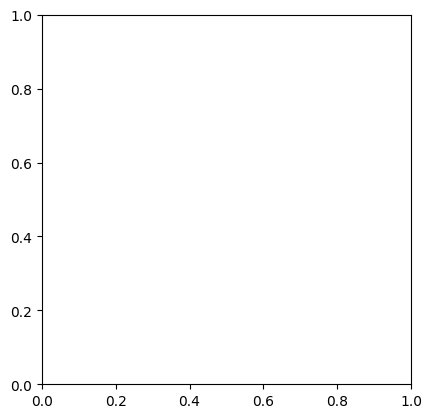

In [11]:
# Visualize one channel of the BEV embedding to see if it is loaded correctly
plt.imshow(pts_bev_embed[0,0], cmap='viridis')

In [9]:
# Create train/test split

# img_bev_embed = bchw_to_bvc(img_bev_embed)
# pts_bev_embed = bchw_to_bvc(pts_bev_embed)

train_split = int(0.8 * len(img_bev_embed)) # 80% of data used for training set, 20% for testing 
X_train, y_train = img_bev_embed[:train_split], pts_bev_embed[:train_split]
X_test, y_test = img_bev_embed[train_split:].squeeze(), pts_bev_embed[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape, "X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

X_train shape: torch.Size([64, 40000, 256]) y_train shape: torch.Size([64, 40000, 256]) X_test shape: torch.Size([17, 40000, 256]) y_test shape: torch.Size([17, 40000, 256])


In [ ]:
X_train = X_test_one
y_train = y_test_one
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)


X_train shape: torch.Size([1, 40000, 256]) y_train shape: torch.Size([1, 40000, 256])


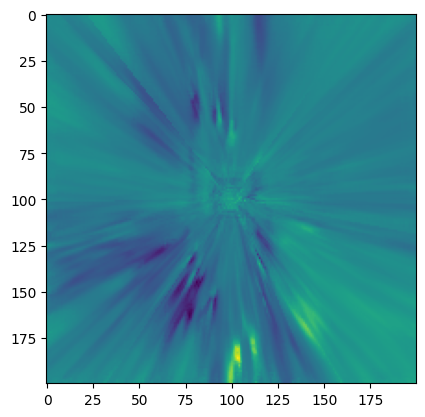

In [13]:
plt.imshow(X_train[0,0].cpu(), cmap='viridis')


In [ ]:
# Create Dataloaders to efficiently push data in batches during training and testing
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 10

train_set = TensorDataset(X_train, y_train)
test_set = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a85aac782d0>, <torch.utils.data.dataloader.DataLoader object at 0x7a874c573450>)
Length of train dataloader: 7 batches of 10


torch.Size([1, 40000, 256]) torch.Size([1, 40000, 256])
tensor(-2.1858, device='cuda:0') tensor(1.9843, device='cuda:0')


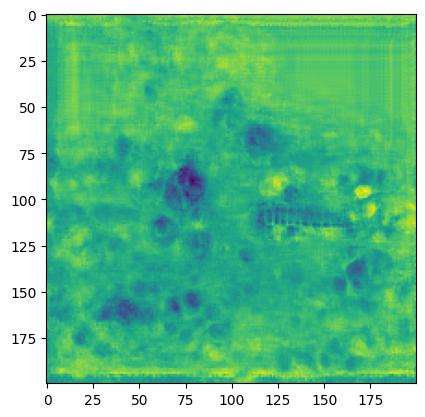

In [32]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(train_features_batch.shape, train_labels_batch.shape)
print(train_features_batch[0,0].min(), train_features_batch[0,0].max())
plt.imshow(bvc_to_bchw(train_labels_batch)[0,0].cpu())

Now we build our torch model

In [16]:
# For reproducibility
torch.manual_seed(42)

# We don't need flatten, as our featuremaps are already flattened.
# Featuremaps are in shape [features, channels]. If in batch they are [batch, features, channels].

class MLPfeaturemapsv0(nn.Module):
    def __init__(self, input_features:int, output_features:int, hidden_units:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )

    def forward(self, x):
        return self.layer_stack(x)
    

class CNNFeatureMappingv0(nn.Module):
    """Learns a mapping from image featuremaps to pointcloud featuremaps using CNNs.
    Args:
        input_channels (int): Number of input channels in the image featuremaps.
        hidden_units (int): Number of hidden units in the CNN layers.
        output_channels (int): Number of output channels in the pointcloud featuremaps.

    Input needs to be in shape of (batch_size, channels, height, width).
    """
    def __init__(self, input_channels:int,
                hidden_units: int,
                output_channels:int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_channels, out_channels=hidden_units, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=1),
            nn.ReLU(inplace=True),
            # nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # nn.MaxPool2d(2)
        )


        self.final = nn.Conv2d(in_channels=hidden_units, out_channels=output_channels, kernel_size=1)


    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.final(x)
        return x

class CNNFeatureMappingv1(nn.Module):
    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        
        # Encoder blocks (contracting path)
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200->100
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100->50
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(1024, 2048, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 50->25
        
        
        # self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)  # 25->12
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(2048, 4096, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, 4096, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder blocks (expanding path)

        
        self.upconv3 = nn.ConvTranspose2d(4096, 2048, kernel_size=2, stride=2)  # 25->50
        self.dec3 = nn.Sequential(
            nn.Conv2d(4096, 2048, kernel_size=3, padding=1),  # 4096 = 2048 + 2048
            nn.ReLU(inplace=True),
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        self.upconv2 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)  # 50->100
        self.dec2 = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),  # 2048 = 1024 + 1024
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # 100->200
        self.dec1 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),  # 1024 = 512 + 512
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Final output layer
        self.final = nn.Conv2d(512, output_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder path - save skip connections
        enc1_out = self.enc1(x)          
        x = self.pool1(enc1_out)          
        
        enc2_out = self.enc2(x)           
        x = self.pool2(enc2_out)          
        
        enc3_out = self.enc3(x)           
        x = self.pool3(enc3_out)          
        
        
        # Bottleneck
        x = self.bottleneck(x)            
        
        # Decoder path - concatenate skip connections        
        x = self.upconv3(x)               
        x = torch.cat([x, enc3_out], dim=1)  
        x = self.dec3(x)                  
        
        x = self.upconv2(x)               
        x = torch.cat([x, enc2_out], dim=1)  
        x = self.dec2(x)                  
        
        x = self.upconv1(x)               
        x = torch.cat([x, enc1_out], dim=1)  
        x = self.dec1(x)                  
        
        # Final layer to get to 200x200
        x = self.final(x)                 
        
        return x
    

class CNNFeatureMappingv2(nn.Module):
    #V2 including batchnorm layers
    def __init__(self, input_channels: int, output_channels: int):
        super().__init__()
        
        # Encoder blocks (contracting path)
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200->100
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100->50
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(1024, 2048, kernel_size=3, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 50->25
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(2048, 4096, kernel_size=3, padding=1),
            nn.BatchNorm2d(4096),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, 4096, kernel_size=3, padding=1),
            nn.BatchNorm2d(4096),
            nn.ReLU(inplace=True)
        )
        
        # Decoder blocks (expanding path)
        self.upconv3 = nn.ConvTranspose2d(4096, 2048, kernel_size=2, stride=2)  # 25->50
        self.dec3 = nn.Sequential(
            nn.Conv2d(4096, 2048, kernel_size=3, padding=1),  # 4096 = 2048 + 2048
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True)
        )
        
        self.upconv2 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)  # 50->100
        self.dec2 = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),  # 2048 = 1024 + 1024
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # 100->200
        self.dec1 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),  # 1024 = 512 + 512
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),    
            nn.ReLU(inplace=True)
        )
        
        # Final output layer
        self.final = nn.Conv2d(512, output_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder path - save skip connections
        enc1_out = self.enc1(x)          
        x = self.pool1(enc1_out)          
        
        enc2_out = self.enc2(x)           
        x = self.pool2(enc2_out)          
        
        enc3_out = self.enc3(x)           
        x = self.pool3(enc3_out)          
        
        # Bottleneck
        x = self.bottleneck(x)            
        
        # Decoder path - concatenate skip connections        
        x = self.upconv3(x)               
        x = torch.cat([x, enc3_out], dim=1)  
        x = self.dec3(x)                  
        
        x = self.upconv2(x)               
        x = torch.cat([x, enc2_out], dim=1)  
        x = self.dec2(x)                  
        
        x = self.upconv1(x)               
        x = torch.cat([x, enc1_out], dim=1)  
        x = self.dec1(x)                  
        
        # Final layer to get to 200x200
        x = self.final(x)                 
        
        return x
    

class MyBEVConsumer(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    
    def forward(self, bev_embed):
        """
        Args:
            bev_embed: (bs, bev_h*bev_w, embed_dim) camera BEV features
        Returns:
        predicted lidar BEV features with same shape
            """
        return self.mlp(bev_embed)

In [24]:
from mmdet.models import HEADS
from mmdet3d.unibev_plugin.models.dense_heads import bev_consumer

input_features, output_features = X_train.shape[1], y_train.shape[1]
# model_0 = MLPfeaturemapsv0(input_features=input_features,
#                            hidden_units=512,
#                            output_features=output_features)

# print("input_features:", input_features, "output_features:", output_features)

# model_0.to(device)


# model_1 = CNNFeatureMappingv0(input_channels=256,
#                               hidden_units=512,
#                               output_channels=256)
# model_1.to(device)

model_1 = CNNFeatureMappingv2(input_channels=256,                            
                              output_channels=256)

# model_1 = MyBEVConsumer(embed_dim=256)

print(torch.cuda.device_count())
# Here we can put the model for data parallelism if needed in future



# path = "/home/mingdayang/mmdetection3d/outputs/train/unibev_nus_LC_cnw_256_modality_dropout_freeze_unibev_train_auxiliary_bev_mapping/latest.pth"

# checkpoint = torch.load(path)

# bev_consumer_state_dict = {}
# prefix = "pts_bbox_head.bev_consumer."

# for key in checkpoint['state_dict'].keys():
#     if key.startswith(prefix):
#         # Remove the prefix to get the model's parameter name
#         new_key = key[len(prefix):]
#         bev_consumer_state_dict[new_key] = checkpoint['state_dict'][key]

# print(f"Extracted {len(bev_consumer_state_dict)} parameters:")
# for key, value in bev_consumer_state_dict.items():
#     print(f"  {key}: {value.shape}")

# model_1.load_state_dict(bev_consumer_state_dict)


checkpoint_path = '/home/mingdayang/mmdetection3d/outputs/train/unibev_freeze_train__flexibleunet_mini_nus_ms_l1_loss/model_latest_l1loss.pth'
checkpoint = torch.load(checkpoint_path)

ModelClass = HEADS.get(checkpoint['model_type'])
print("ModelClass:", ModelClass, "type:", type(ModelClass))
print("Model config:", checkpoint['model_config'])
print("ModelClass accepted config keys:", ModelClass.__init__.__code__.co_varnames)
for k, v in checkpoint['model_config'].items():
    print(k, ":", v)
# print(checkpoint['model_config']['loss_config'])
# checkpoint['model_config'].pop('reduction')
# checkpoint['model_config']['loss_config'] = None
model = ModelClass(**checkpoint['model_config'])
model.load_state_dict(checkpoint['state_dict'])
print("Model loaded successfully.")
print("         Model info          ")
print("-----------------------------")
print(model)
print(vars(model))

model_1 = nn.DataParallel(model_1, device_ids=[6,7], output_device=device)
model_1.to(device)


8
ModelClass: <class 'mmdet3d.unibev_plugin.models.dense_heads.bev_consumer.FlexibleUNet'> type: <class 'abc.ABCMeta'>
Model config: {'input_channels': 256, 'output_channels': 256, 'channel_sizes': [256, 256, 256, 256], 'bev_h': 200, 'bev_w': 200}
ModelClass accepted config keys: ('self', 'input_channels', 'output_channels', 'channel_sizes', 'bev_h', 'bev_w')
input_channels : 256
output_channels : 256
channel_sizes : [256, 256, 256, 256]
bev_h : 200
bev_w : 200
Model loaded successfully.
         Model info          
-----------------------------
FlexibleUNet(
  (l1_loss): L1Loss()
  (enc1): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)

DataParallel(
  (module): CNNFeatureMappingv2(
    (enc1): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (enc2): Sequential(
      (0): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
  

In [ ]:
from mmdet.models import HEADS
from mmdet3d.unibev_plugin.models.dense_heads import bev_consumer
model_name = 'UnetConcatenatedPCA'
model_class = HEADS.get(model_name)
input_channels=256
output_channels=256
channel_sizes=[256, 512, 1024, 2048]
model_1 = model_class(input_channels=input_channels, output_channels=output_channels, channel_sizes=channel_sizes)
# model_1 = nn.DataParallel(model_1, device_ids=[7], output_device=device)
model_1.to(device)

UnetConcatenatedPCA(
  (l1_loss): L1Loss()
  (input_pca): Sequential(
    (0): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (1): GroupNorm(32, 256, eps=1e-05, affine=True)
  )
  (enc1): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    (2): SiLU(inplace=True)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(32, 256, eps=1e-05, affine=True)
    (5): SiLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(32, 512, eps=1e-05, affine=True)
    (2): SiLU(inplace=True)
    (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(32, 512, eps=1e-05, affine=True)
    (5): SiLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, p

In [12]:
# l1_loss = nn.L1Loss()
# cos_loss = nn.CosineSimilarity(dim=0)
loss_fn = nn.L1Loss()

learning_rate = 1e-2
weight_decay = 1e-2
epochs = 200


# l = cos_loss(train_features_batch, train_labels_batch)
accuracy_fn = nn.CosineSimilarity(dim=0)
optimizer = torch.optim.AdamW(params=model_1.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=200, T_mult=1, eta_min=1e-6)
scheduler2 = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=50)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, 
                                schedulers=[scheduler2, scheduler1], 
                                milestones=[20],
                            )
# # l.mean()
# l1_loss(train_features_batch, train_labels_batch)

In [13]:
import wandb

config = {
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "batch_size": BATCH_SIZE,
    "architecture": model_name,
    "optimizer": optimizer,
    "loss_function": loss_fn,
    "epochs": epochs,
    "scheduler": scheduler
}

In [17]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: mln9d4 (mln9d4-tu-delft). Use `wandb login --relogin` to force relogin


True

In [14]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time
test_epoch_losses = []
train_epoch_losses = []

Here we define the training loop

In [15]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)

# test_epoch_losses = []
# train_epoch_losses = []
# Create training and testing loop
with wandb.init(project="manual-training-notebook", config=config) as run:  
    run.watch(model_1, log="all", log_freq=10)
    for epoch in tqdm(range(epochs)):
        test_loss = 0
        train_loss = 0
        print(f"Epoch: {epoch}\n-------")
        ### Training
        model_1.train() 
        # Add a loop to loop through training batches
        for batch, (X, y) in enumerate(train_dataloader):

            # Move data to device
            X, y = X.to(device), y.to(device)
            X, y = X.contiguous(), y.contiguous()
            print("X shape in training loop:", X.shape)
            # 1. Forward pass
            y_pred = model_1(X)
            # 2. Calculate loss (per batch)
            loss = loss_fn(y_pred, y)

            train_loss += loss.item() # accumulatively add up the loss per epoch 

            # 3. Optimizer zero grad
            optimizer.zero_grad()

            # 4. Loss backward
            loss.backward()

            # 5. Optimizer step
            optimizer.step()
            scheduler.step()
            current_lr = optimizer.param_groups[-1]['lr'],
            run.log({"learning_rate": current_lr[0]})

            # Print out how many samples have been seen
            if batch % 3 == 0:
                print(f"Looked at {batch * BATCH_SIZE}/{len(train_dataloader.dataset)} samples")

        # Divide total train loss by length of train dataloader (average loss per batch per epoch)
        train_loss /= len(train_dataloader)
        train_epoch_losses.append(train_loss)
        ### Testing
        # Setup variables for accumulatively adding up loss and accuracy 
        
        if True:
            model_1.eval()
            with torch.inference_mode():
                for X, y in test_dataloader:
                    # Move to device
                    X, y = X.to(device), y.to(device)
                    X, y = X.contiguous(), y.contiguous()
                    # 1. Forward pass
                    test_pred = model_1(X)
                
                    # 2. Calculate loss (accumulatively)
                    test_loss += loss_fn(test_pred, y)


                
                # Calculations on test metrics need to happen inside torch.inference_mode()
                # Divide total test loss by length of test dataloader (per batch)
                test_loss /= len(test_dataloader)
                test_epoch_losses.append(test_loss.cpu())
        run.log({"epoch": epoch, "training_loss": train_loss, "validation_loss": test_loss})


        ## Print out what's happening
        # print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")
        print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}%\n")
run.finish()
# Calculate training time      
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_1.parameters()).device))

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: mln9d4 (mln9d4-tu-delft). Use `wandb login --relogin` to force relogin


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch: 0
-------
X shape in training loop: torch.Size([10, 40000, 256])
Looked at 0/64 samples
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
Looked at 30/64 samples
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([4, 40000, 256])
Looked at 60/64 samples

Train loss: 0.27932 | Test loss: 0.18338%

Epoch: 1
-------
X shape in training loop: torch.Size([10, 40000, 256])
Looked at 0/64 samples
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
Looked at 30/64 samples
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([10, 40000, 256])
X shape in training loop: torch.Size([4, 40000, 256])
Looked at 60/64 samples

Train loss:

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇████
learning_rate,█▇▅▄▃▂▁█▆▆▄▄▂▁████▄▄▁▁▁▅▃▂▁▇▇▅▁▁▇▆▅▁▇▇▇▂
training_loss,█▇▇▇▇▇▆▆▅▅▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁
validation_loss,█▇▇▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▆▅▅▄▄▄▄▄▄▃▂▂▂▄▂▂▁▁▁▁▁
epoch,199
learning_rate,0.00025
training_loss,0.10902
validation_loss,0.12205


Train time on cuda:2: 1869.241 seconds


In [89]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(device)

In [116]:
def plot_loss_curves(train_losses, test_losses):
    """Plots training and test loss curves against epochs."""
    epochs = range(1, len(train_losses) + 1)

    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Test Loss over Epochs', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

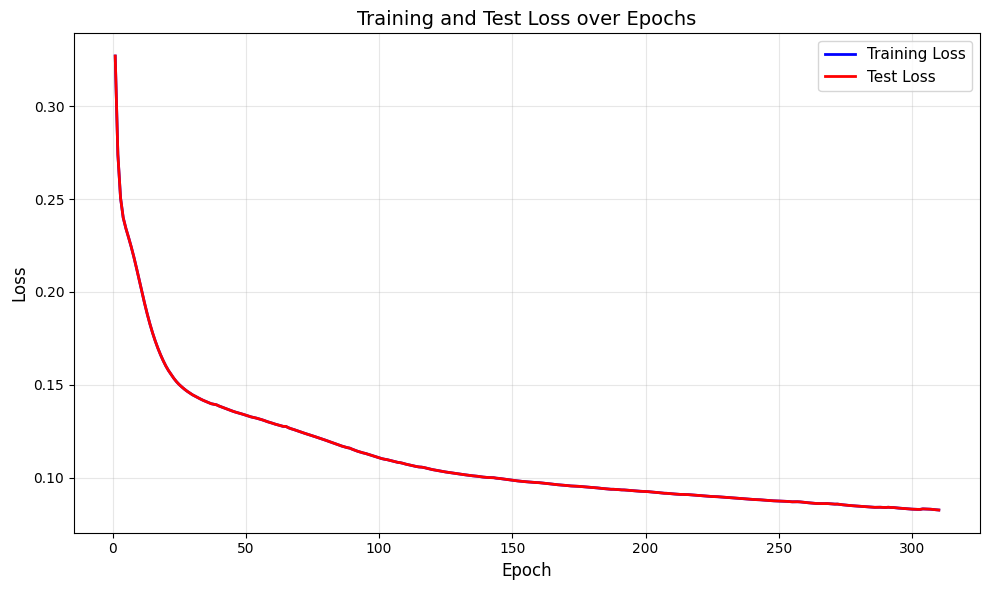

In [129]:
plot_loss_curves(train_epoch_losses, train_epoch_losses)
# train_loss

In [16]:
#Save the model
from pathlib import Path

# Create model directory if it doesn't exist
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "UNetConcatenatedPCA27012026_usual-spong-6.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME



In [17]:
temp_ = {}
temp_['model_type'] = model_name
temp_['model_config'] = {'input_channels': 256, 'output_channels': 256, 'bev_h': 200, 'bev_w': 200, 'channel_sizes': [256, 512, 1024, 2048]}
temp_['state_dict'] = model_1.state_dict()

In [18]:
torch.save(temp_, MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: models/UNetConcatenatedPCA27012026_usual-spong-6.pth


In [ ]:
from collections import OrderedDict

state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)

new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith("module."):
        k = k[len("module."):]  # remove "module."
    new_state_dict[k] = v

model_1.load_state_dict(new_state_dict)
model_1.to(device)

CNNFeatureMappingv2(
  (enc1): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(32, 512, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(32, 512, eps=1e-05, affine=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(32, 1024, eps=1e-05, affine=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GroupNorm(32, 1024, eps=1e-05, affine=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(1024, 2048, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(32

In [ ]:
# Load the model
model_1 = CNNFeatureMappingv2(input_channels=256,                            
                              output_channels=256)
model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
model_1.to(device)

RuntimeError: Error(s) in loading state_dict for CNNFeatureMappingv2:
	Missing key(s) in state_dict: "enc1.0.weight", "enc1.0.bias", "enc1.1.weight", "enc1.1.bias", "enc1.3.weight", "enc1.3.bias", "enc1.4.weight", "enc1.4.bias", "enc2.0.weight", "enc2.0.bias", "enc2.1.weight", "enc2.1.bias", "enc2.3.weight", "enc2.3.bias", "enc2.4.weight", "enc2.4.bias", "enc3.0.weight", "enc3.0.bias", "enc3.1.weight", "enc3.1.bias", "enc3.3.weight", "enc3.3.bias", "enc3.4.weight", "enc3.4.bias", "bottleneck.0.weight", "bottleneck.0.bias", "bottleneck.1.weight", "bottleneck.1.bias", "bottleneck.3.weight", "bottleneck.3.bias", "bottleneck.4.weight", "bottleneck.4.bias", "upconv3.weight", "upconv3.bias", "dec3.0.weight", "dec3.0.bias", "dec3.1.weight", "dec3.1.bias", "dec3.3.weight", "dec3.3.bias", "dec3.4.weight", "dec3.4.bias", "upconv2.weight", "upconv2.bias", "dec2.0.weight", "dec2.0.bias", "dec2.1.weight", "dec2.1.bias", "dec2.3.weight", "dec2.3.bias", "dec2.4.weight", "dec2.4.bias", "upconv1.weight

In [ ]:
model_1.eval()

y_pred = None

# x_sample_ori = X_test[0]
# print(x_sample_ori.shape)
# x_sample_dimmed = x_sample_ori.reshape(1, 256, 40000).permute(0, 2 ,1).to(device)
# print(x_sample_dimmed.shape)
with torch.inference_mode():
    X_train = X_train
    y_pred = model_1(X_train)
    # y_pred_train = model_1(X_train.to(device))

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [21]:
print(y_pred.shape)
y_pred_correct_dim = y_pred.permute(0, 2, 1).reshape(1, 256, 200, 200)
print(y_pred_correct_dim.shape)

torch.Size([1, 40000, 256])
torch.Size([1, 256, 200, 200])


In [31]:
torch.cuda.empty_cache()

In [25]:
model_1.eval()
BATCH_INFER = 8  # pick a size that fits memory

infer_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=BATCH_INFER,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

pred_chunks = []
with torch.inference_mode():
    for (xb,) in infer_loader:
        xb = xb.to(device, non_blocking=True).contiguous()
        yb = model_1(xb)
        pred_chunks.append(yb.cpu())  # keep outputs on CPU to save GPU memory
        del xb, yb
        torch.cuda.empty_cache()

y_pred_test = torch.cat(pred_chunks, dim=0)  # shape: [len(X_train), 256, 200, 200]

In [123]:
y_pred_test.shape

# X_test.shape

# y_pred_train.shape

torch.Size([17, 40000, 256])

In [26]:
def max_pool_activations(feature_tensor, key):
    """Computes the max-pooled activations for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    max_pooled_activation = torch.max(activation, dim=2)[0]  # Max pool across channels
    max_pooled_activation = max_pooled_activation.cpu().numpy()  # Convert to numpy array
    max_pooled_activation = np.flip(max_pooled_activation, axis=0)  # Flip vertically for correct orientation

    return max_pooled_activation

def mean_activations(feature_tensor, key):
    """Computes the mean activations for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    mean_activation = torch.mean(activation, dim=2)  # Calculate mean across channels
    mean_activation = mean_activation.cpu().numpy()  # Convert to numpy array
    mean_activation = np.flip(mean_activation, axis=0)  # Flip vertically for correct orientation

    return mean_activation


def channel_activations(feature_tensor, key, channel):
    """Computes the activations for a specific channel for the given key from the given feature tensor"""
    activation = feature_tensor[key].squeeze(0)  # Get corresponding feature map that aligns with the key
    activation = activation.view(200, 200, -1)  # Reshape to (200, 200, num_channels)

    channel_activation = activation[:,:,channel]  # Extract the specified channel
    channel_activation = channel_activation.cpu().numpy()  # Convert to numpy array
    channel_activation = np.flip(channel_activation, axis=0)  # Flip vertically for correct orientation

    return channel_activation

def figure_to_image(fig):
    fig.canvas.draw()  # Render the figure
    # Convert to a numpy array
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)  # Close the figure after conversion
    return image

def plot_singular_BEV_pointcloud(sample_token, nusc):
    """Plots the BEV point cloud for a given sample token."""
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    sample_fig = nusc.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True)
    sample_image = figure_to_image(sample_fig)
    ax.imshow(sample_image)
    ax.set_title(f"BEV Point Cloud for Sample Token: {sample_token}")
    ax.axis('off')
    ax.set_ylim(800, 106)
    ax.set_xlim(106, 800)
    plt.tight_layout()
    plt.close(sample_fig)
    plt.show()

def plot_singular_feature_map(feature_tensor, key, method, channel=None):
    """Plots a singular feature map based on the specified method.
    
    Args:
        feature_tensor (tensor): The feature tensor containing various feature maps.
        key (str): The key to access the desired feature map.
        method (str): The method to reduce the feature map ('channel', 'max_pool', 'mean').
        channel (int, optional): The channel index to visualize if method is 'channel

    Available methods are 'channel', 'max_pool', and 'mean'.
    """
    fig, axs = plt.subplots(1, 1, figsize=(6,6))

    activation = None

    if method == 'channel':
        activation = channel_activations(feature_tensor, key, channel)
    elif method == 'max_pool':
        activation = max_pool_activations(feature_tensor, key)
    elif method == 'mean':
        activation = mean_activations(feature_tensor, key)
    else:
        raise ValueError(f"Unknown method: {method}")

    im = axs.imshow(activation, cmap='viridis')
    axs.set_title(f"{method} from {key}")
    axs.grid()
    fig.colorbar(im, ax=axs, orientation='vertical', shrink=0.7)
    plt.tight_layout()
    plt.show()

def plot_camera_against_lidar_feature_map(feature_tensor,
                                          method,
                                          channel=None,
                                          share_colorbar=True):
    """Plots camera BEV feature map against LiDAR BEV feature map."""
    img_key = 'img_bev_embed'
    pts_key = 'pts_bev_embed'

    fig, axs = plt.subplots(1, 2, figsize=(12,6))

    img_activation, pts_activation = None, None

    if method == 'channel':
        img_activation = channel_activations(feature_tensor, img_key, channel)
        pts_activation = channel_activations(feature_tensor, pts_key, channel)
    elif method == 'max_pool':
        img_activation = max_pool_activations(feature_tensor, img_key)
        pts_activation = max_pool_activations(feature_tensor, pts_key)
    elif method == 'mean':
        img_activation = mean_activations(feature_tensor, img_key)
        pts_activation = mean_activations(feature_tensor, pts_key)
    else:
        raise ValueError(f"Unknown method: {method}")

    # axs[0].imshow(img_activation, cmap='viridis')
    channel_str = f" {channel}" if method == 'channel' else ""
    axs[0].set_title(f"({img_key}) Feature Map {method} {channel_str}")
    axs[0].grid()

    # axs[1].imshow(pts_activation, cmap='viridis')
    axs[1].set_title(f"({pts_key}) Feature Map {method} {channel_str}")
    axs[1].grid()
    
    # Ensure both plots share the same color scale
    if share_colorbar:
        vmin = min(np.min(img_activation), np.min(pts_activation))
        vmax = max(np.max(img_activation), np.max(pts_activation))
        im0 = axs[0].imshow(img_activation, cmap='viridis', vmin=vmin, vmax=vmax)
        im1 = axs[1].imshow(pts_activation, cmap='viridis', vmin=vmin, vmax=vmax)
        # Add a single colorbar for both plots
        # Place the colorbar next to the plots on the right side
        pos_right = axs[1].get_position()  # Position of the right plot
        cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])  # Adjust to the height of the subplot
        fig.colorbar(im1, cax=cbar_ax)
    
        plt.tight_layout(rect=[0, 0, 0.9, 1])
    else:
        axs[0].imshow(img_activation, cmap='viridis')
        axs[1].imshow(pts_activation, cmap='viridis')
        plt.tight_layout()
    plt.show()


def plot_train_pred_test(X, y, y_pred, channel=0):
    fig, axs = plt.subplots(1, 3, figsize=(18,6))

    # Ensure all inputs are numpy arrays
    X_np = X[0,:,:].cpu().numpy() if torch.is_tensor(X) else X[0,:,:]
    y_np = y[0,:,:].cpu().numpy() if torch.is_tensor(y) else y[0,:,:]
    y_pred_np = y_pred[0,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y_pred[0,:,:]
    
    # Calculate shared color scale ONLY between predictions
    vmin = min(np.min(y_np), np.min(y_pred_np))
    vmax = max(np.max(y_np), np.max(y_pred_np))
    
    im0 = axs[0].imshow(X_np, cmap='viridis')
    axs[0].set_title("Input Image Feature Map")
    
    im1 = axs[1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[1].set_title("Ground Truth LiDAR Feature Map")
    
    im2 = axs[2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[2].set_title("Predicted LiDAR Feature Map")
    
    # Add shared colorbar
    pos_right = axs[2].get_position()
    cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
    fig.colorbar(im2, cax=cbar_ax)
    
    # plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


def multiple_channels(X, y, y_pred, channels, scene=0):
    fig, axs = plt.subplots(channels, 3, figsize=(9, 3 * channels))

    for i, channel in enumerate(range(channels)):
        # Ensure all inputs are numpy arrays
        X_np = X[scene,channel,:,:].cpu().numpy() if torch.is_tensor(X) else X[scene,channel,:,:]
        y_np = y[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y) else y[scene,channel,:,:]
        y_pred_np = y_pred[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y[scene,channel,:,:]
        
        # Calculate shared color scale ONLY between predictions
        vmin = min(np.min(y_np), np.min(y_pred_np))
        vmax = max(np.max(y_np), np.max(y_pred_np))
        
        im0 = axs[i, 0].imshow(X_np, cmap='viridis')
        axs[i, 0].set_title(f"Ch {channel} Sc {scene} - Input Image", fontsize=10)
        
        im1 = axs[i, 1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 1].set_title(f"Ch {channel} Sc {scene}  - GT LiDAR", fontsize=10)
        
        im2 = axs[i, 2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 2].set_title(f"Ch {channel} Sc {scene} - Pred LiDAR", fontsize=10)

        # Add shared colorbar for each row
        pos_right = axs[i, 2].get_position()
        cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
        fig.colorbar(im2, cax=cbar_ax)
    
    plt.show()

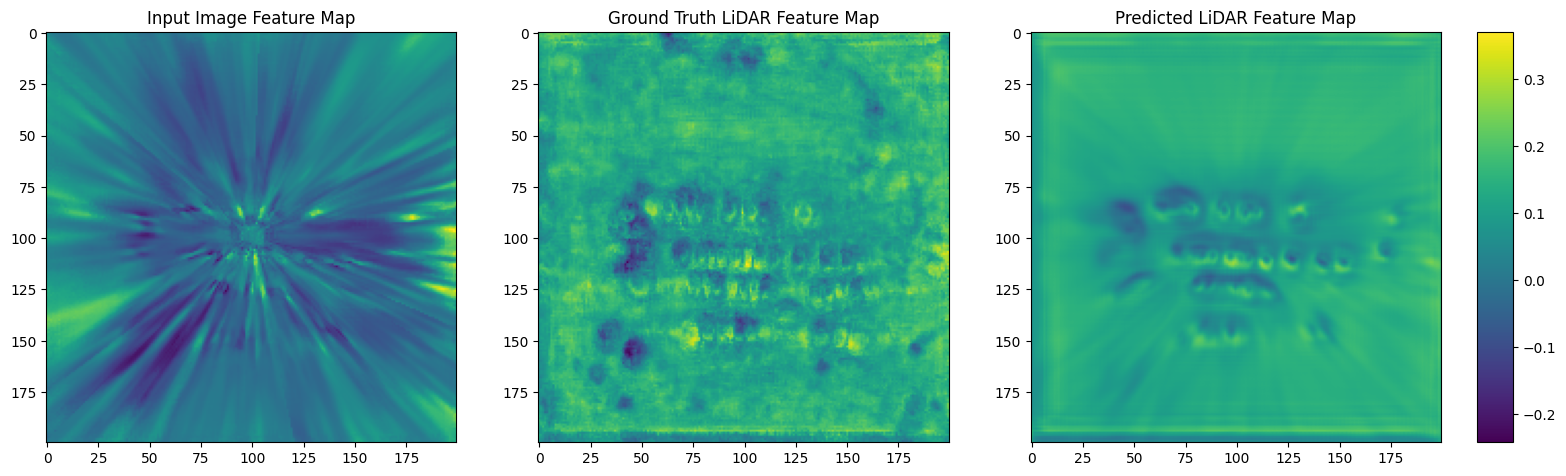

In [27]:
scene=1
channel=0
# plot_train_pred_test(bvc_to_bchw(X_train)[scene,:,:].cpu(), bvc_to_bchw(y_train)[scene,:,:].cpu(), bvc_to_bchw(y_pred_test)[scene,:,:].cpu(), channel=channel)
# plot_train_pred_test(X_test[scene,:,:].cpu(), y_test[scene,:,:].cpu(), y_pred[scene,:,:].cpu(), channel=channel)
plot_train_pred_test(bvc_to_bchw(X_test)[scene,:,:].cpu(), bvc_to_bchw(y_test)[scene,:,:].cpu(), bvc_to_bchw(y_pred_test)[scene,:,:].cpu(), channel=channel)

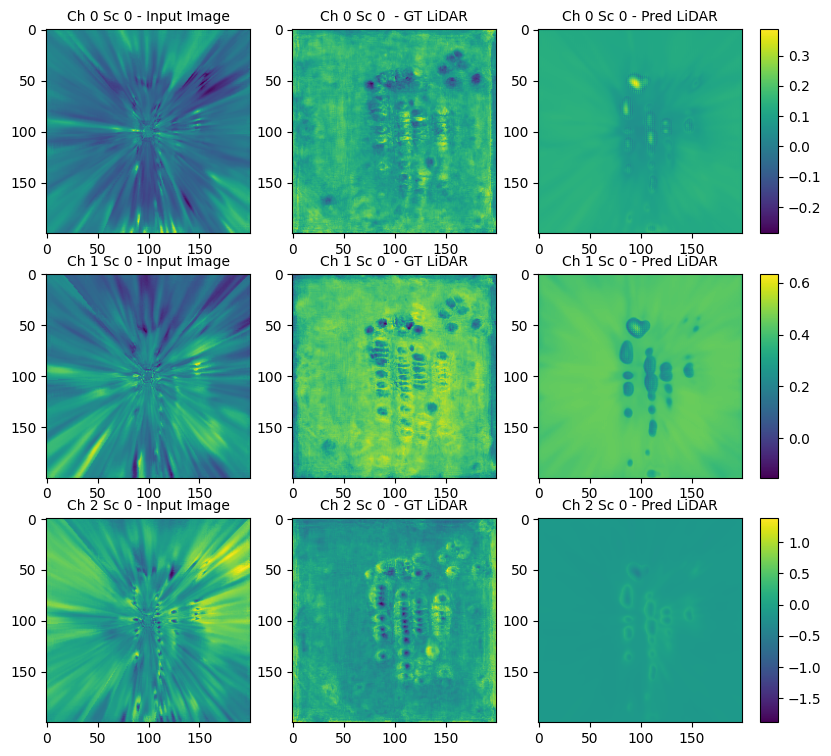

: 

In [ ]:
multiple_channels((X_test).cpu(), (y_test).cpu(), (y_pred_test).cpu(), channels=3,scene=0)
# multiple_channels(X_train.cpu(), y_train.cpu(), y_pred_train.cpu(), channels=3,scene=0)
# multiple_channels(X_test.cpu(), y_test.cpu(), y_pred_test.cpu(), channels=3,scene=0)
